In [89]:
from scipy.fftpack import rfft, irfft
from matplotlib.pylab import plt, log, polyfit
import numpy as np
import sympy as sy

L = 1
N = 100
dx = L/N

X = np.linspace(0,L-dx,N)

f = lambda x : np.sin(np.pi/2+x)
g = lambda x : np.sin(np.pi/4*x)

#Calcul des lambda k de ma base
lambdak = [0]
for k in np.arange(1,N//2+1) :
		lambdak.append((2*np.pi*k/L)**2)
		lambdak.append((2*np.pi*k/L)**2)


#print(len(U),len(F))
Fchap = rfft(f(X))
Gchap = rfft(g(X))
print(len(Fchap), len(Gchap), len(lambdak))

Uchap = [((lambdak[i]+1)*Fchap[i]+Gchap[i])/((lambdak[i]+1)**2+1) for i in range(len(lambdak))]
Vchap = [Uchap[i]*(lambdak[i]+1)-Fchap[i] for i in range(len(lambdak))]
U = irfft(Uchap)
V = irfft(Vchap)

plt.title('u v')

plt.plot(X,U)
plt.plot(X,V)
plt.show()

plt.title('f g')
plt.plot(X,f(X))
plt.plot(X,g(X))
plt.show()

100 100 101


IndexError: index 100 is out of bounds for axis 0 with size 100

In [ ]:
x, k, l = sy.symbols('x k l')
v = lambda x : (x-x**2)**3
u = lambda x : (x-x**2)**2

phic =  sy.cos(2*k*sy.pi*x/l)
phis = sy.sin(2*k*sy.pi*x/l)

dxu = sy.diff(u(x), x)
dxxu = sy.diff(dxu, x)

dxv = sy.diff(v(x), x)
dxxv = sy.diff(dxv, x)
display(dxv)
display(dxu)

dxpc = sy.diff(phic, x)
dxxpc = sy.diff(dxpc, x)

dxps = sy.diff(phis, x)
dxxps = sy.diff(dxps, x)

display(dxxpc)
display(dxxps)

f = u(x)-v(x)-dxxu
g = v(x)+u(x)-dxxv

display(f)
display(g)

fnump = sy.lambdify(x, f, 'numpy')
gnump = sy.lambdify(x, g, 'numpy')

unump = sy.lambdify(x, u(x), 'numpy')
vnump = sy.lambdify(x, v(x), 'numpy')

L = 1
def resol(N) :
	dx = L/N

	X = np.linspace(0,L-dx,N)

	F = fnump(X)
	G = gnump(X)
	Fchap = rfft(F)
	Gchap = rfft(G)
	#print(len(Fchap), len(Gchap), len(lambdak))

	#Calcul des lambda k de ma base
	lambdak = [0]
	for k in np.arange(1,N//2+1) :
			lambdak.append((2*np.pi*k/L)**2)
			lambdak.append((2*np.pi*k/L)**2)
	print(lambdak)


	Uchap = [((lambdak[i]+1)*Fchap[i]+Gchap[i])/((lambdak[i]+1)**2+1) for i in range(len(Fchap))]
	Vchap = [Uchap[i]*(lambdak[i]+1)-Fchap[i] for i in range(len(Fchap))]
	U = irfft(Uchap)#-0.505
	V = irfft(Vchap)#-0.58

	fig, axs = plt.subplots(2, 2, figsize=(15, 5))
	fig.suptitle(f'N = {N}')
	axs[0,0].set_title('u')
	axs[0,0].plot(X,unump(X))
	axs[0,0].plot(X,U)
	axs[0,0].legend(['exacte', 'approchée'])

	axs[0,1].set_title('v')
	axs[0,1].plot(X,vnump(X))
	axs[0,1].plot(X,V)
	axs[0,1].legend(['exacte','approchée'])

	axs[1,0].set_title('Err U')
	axs[1,0].plot(X,abs(unump(X)-U))
	axs[1,1].set_title('Err V')
	axs[1,1].plot(X,abs(vnump(X)-V))
	plt.show()

	return (sum(abs(unump(X)-U))/len(U), sum(abs(vnump(X)-V))/len(V))

(3 - 6*x)*(-x**2 + x)**2

(2 - 4*x)*(-x**2 + x)

-4*pi**2*k**2*cos(2*pi*k*x/l)/l**2

-4*pi**2*k**2*sin(2*pi*k*x/l)/l**2

-4*x**2 + 4*x - (1 - 2*x)*(2 - 4*x) - (-x**2 + x)**3 + (-x**2 + x)**2

-(2 - 4*x)*(3 - 6*x)*(-x**2 + x) + (-x**2 + x)**3 + 7*(-x**2 + x)**2

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358]


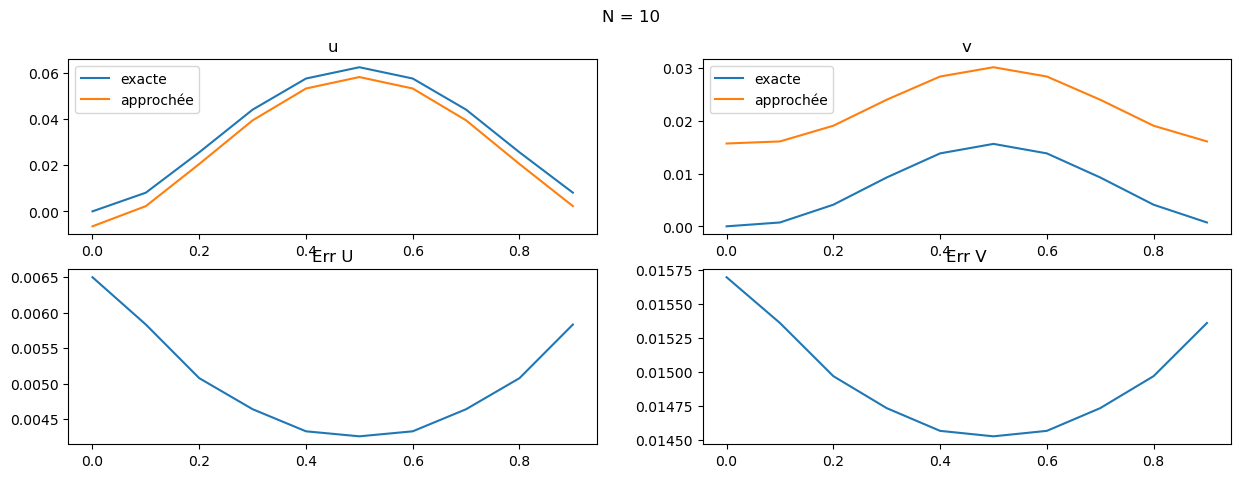

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433]


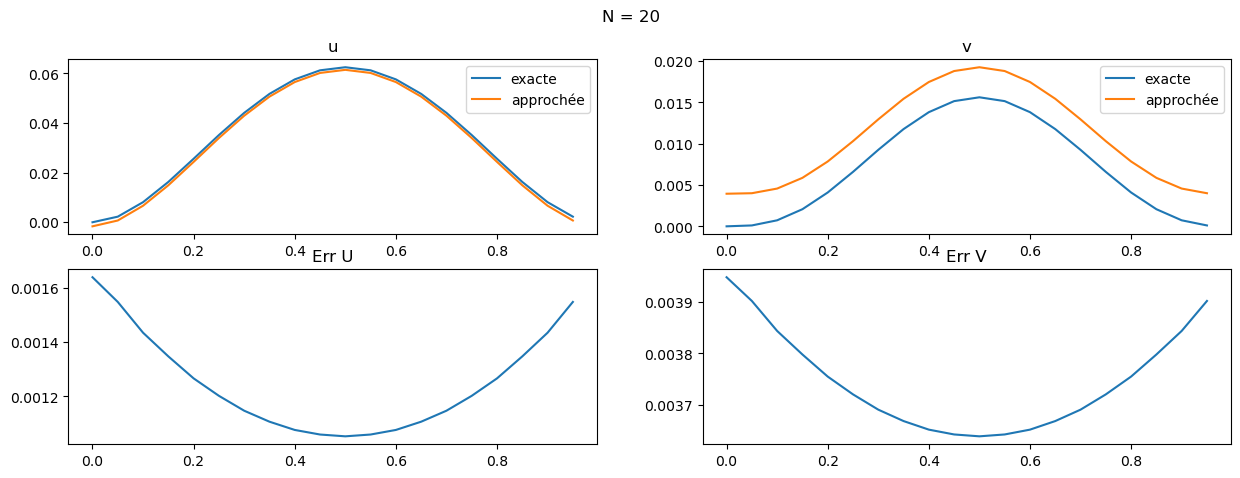

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042]


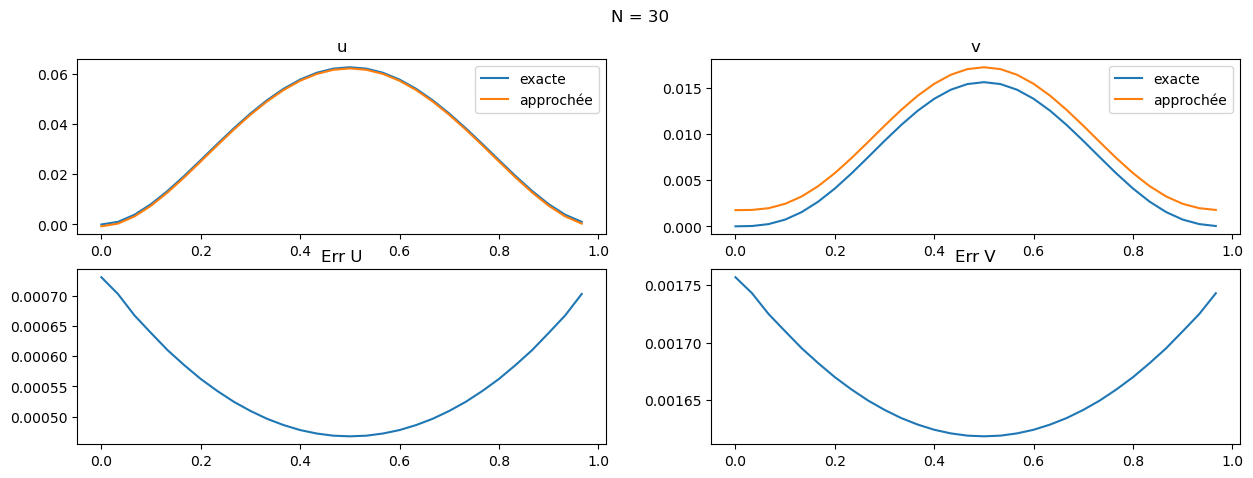

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042, 10106.474906715503, 10106.474906715503, 11409.262687659299, 11409.262687659299, 12791.007303811808, 12791.007303811808, 14251.708755173031, 14251.708755173031, 15791.367041742973, 15791.367041742973]


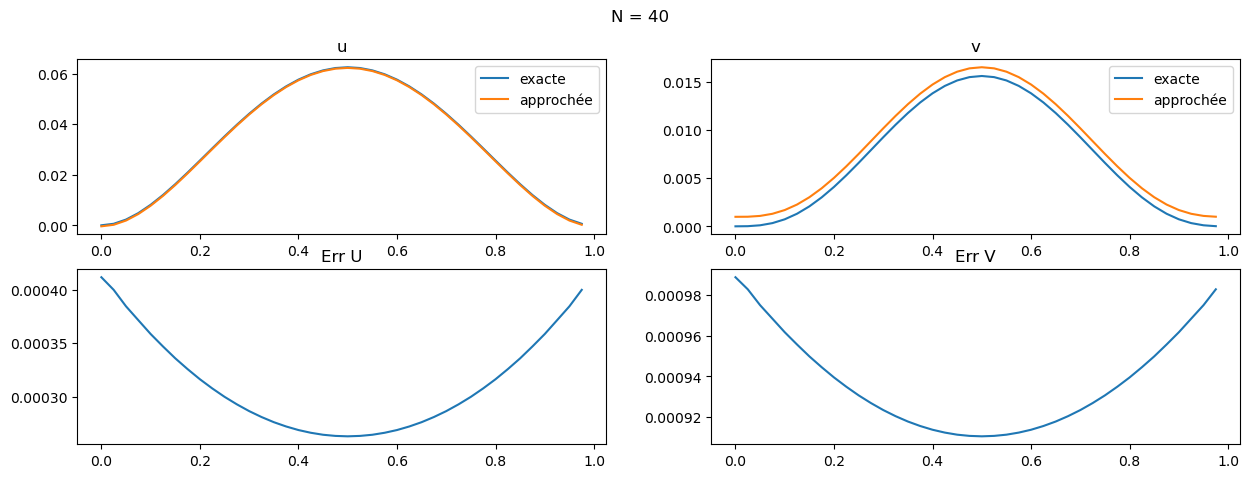

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042, 10106.474906715503, 10106.474906715503, 11409.262687659299, 11409.262687659299, 12791.007303811808, 12791.007303811808, 14251.708755173031, 14251.708755173031, 15791.367041742973, 15791.367041742973, 17409.98216352163, 17409.98216352163, 19107.554120508994, 19107.554120508994, 20884.08291270508, 20884.08291270508, 22739.56854010988, 22739.56854010988, 24674.011002723397, 24674.011002723397]


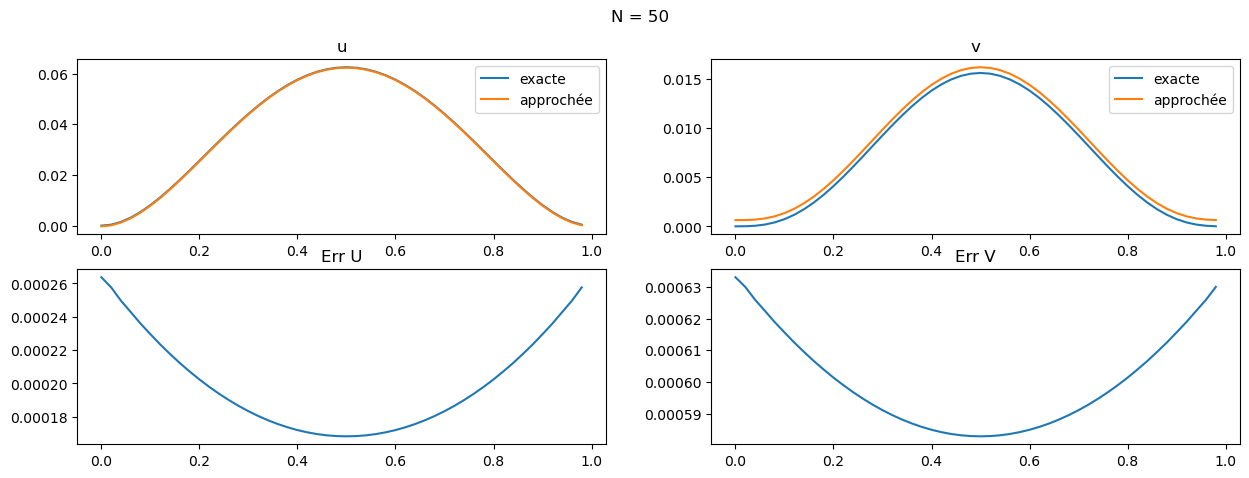

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042, 10106.474906715503, 10106.474906715503, 11409.262687659299, 11409.262687659299, 12791.007303811808, 12791.007303811808, 14251.708755173031, 14251.708755173031, 15791.367041742973, 15791.367041742973, 17409.98216352163, 17409.98216352163, 19107.554120508994, 19107.554120508994, 20884.08291270508, 20884.08291270508, 22739.56854010988, 22739.56854010988, 24674.011002723397, 24674.011002723397, 26687.410300545627, 2668

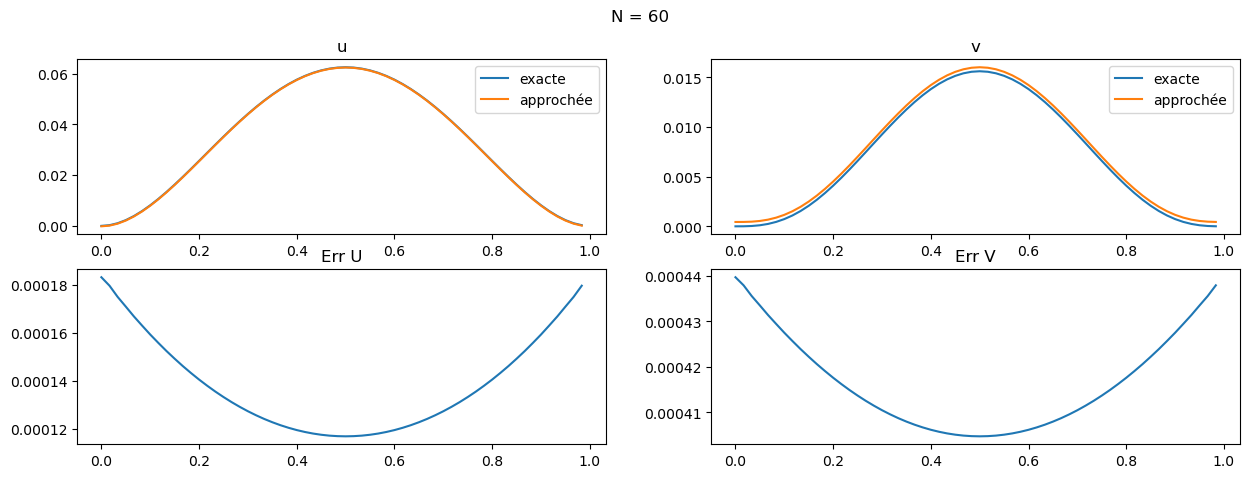

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042, 10106.474906715503, 10106.474906715503, 11409.262687659299, 11409.262687659299, 12791.007303811808, 12791.007303811808, 14251.708755173031, 14251.708755173031, 15791.367041742973, 15791.367041742973, 17409.98216352163, 17409.98216352163, 19107.554120508994, 19107.554120508994, 20884.08291270508, 20884.08291270508, 22739.56854010988, 22739.56854010988, 24674.011002723397, 24674.011002723397, 26687.410300545627, 2668

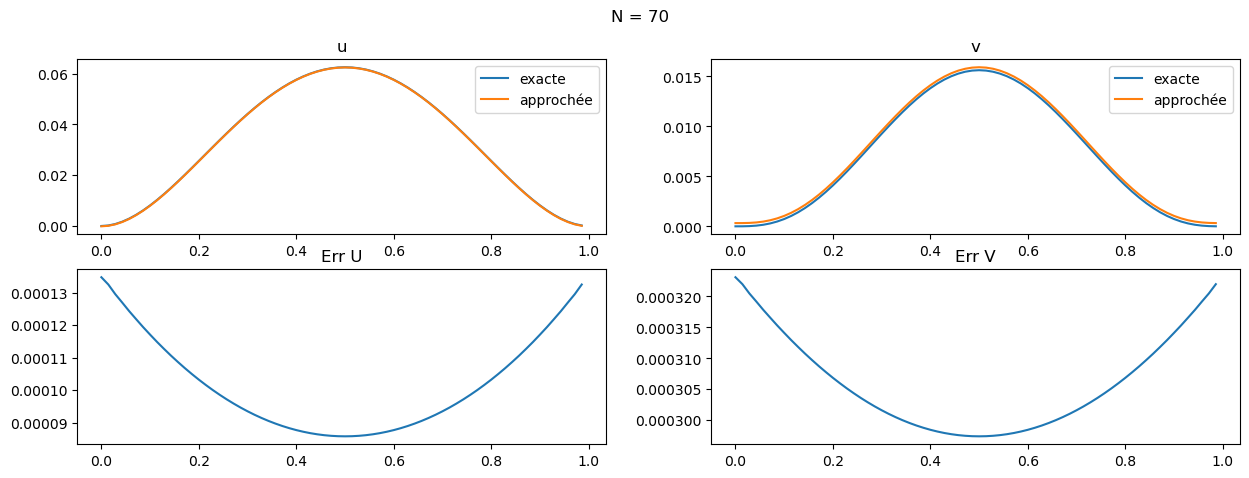

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042, 10106.474906715503, 10106.474906715503, 11409.262687659299, 11409.262687659299, 12791.007303811808, 12791.007303811808, 14251.708755173031, 14251.708755173031, 15791.367041742973, 15791.367041742973, 17409.98216352163, 17409.98216352163, 19107.554120508994, 19107.554120508994, 20884.08291270508, 20884.08291270508, 22739.56854010988, 22739.56854010988, 24674.011002723397, 24674.011002723397, 26687.410300545627, 2668

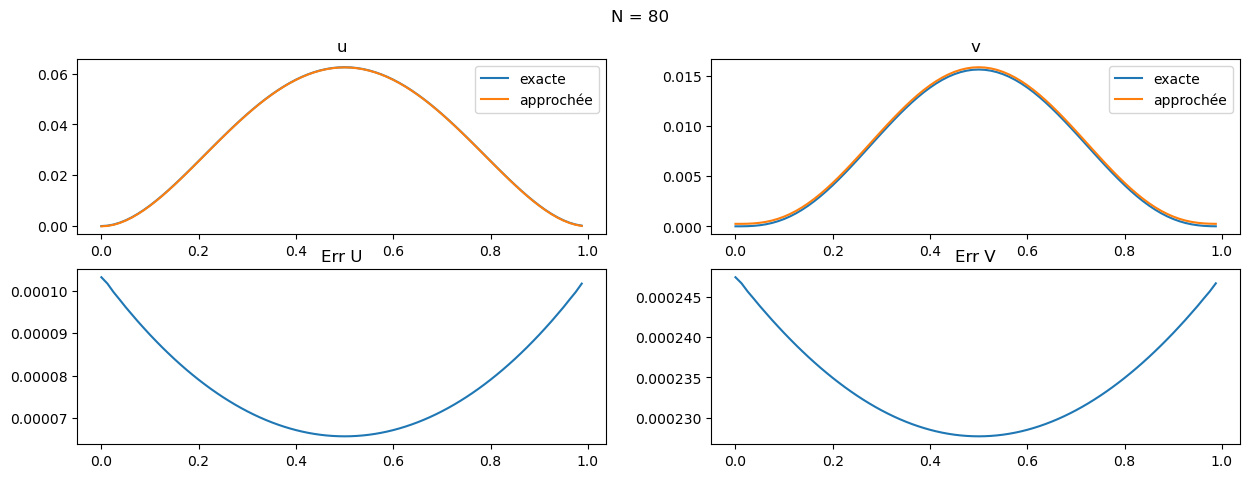

[0, 39.47841760435743, 39.47841760435743, 157.91367041742973, 157.91367041742973, 355.3057584392169, 355.3057584392169, 631.6546816697189, 631.6546816697189, 986.9604401089358, 986.9604401089358, 1421.2230337568676, 1421.2230337568676, 1934.4424626135142, 1934.4424626135142, 2526.6187266788756, 2526.6187266788756, 3197.751825952952, 3197.751825952952, 3947.8417604357433, 3947.8417604357433, 4776.8885301272485, 4776.8885301272485, 5684.89213502747, 5684.89213502747, 6671.852575136407, 6671.852575136407, 7737.769850454057, 7737.769850454057, 8882.64396098042, 8882.64396098042, 10106.474906715503, 10106.474906715503, 11409.262687659299, 11409.262687659299, 12791.007303811808, 12791.007303811808, 14251.708755173031, 14251.708755173031, 15791.367041742973, 15791.367041742973, 17409.98216352163, 17409.98216352163, 19107.554120508994, 19107.554120508994, 20884.08291270508, 20884.08291270508, 22739.56854010988, 22739.56854010988, 24674.011002723397, 24674.011002723397, 26687.410300545627, 2668

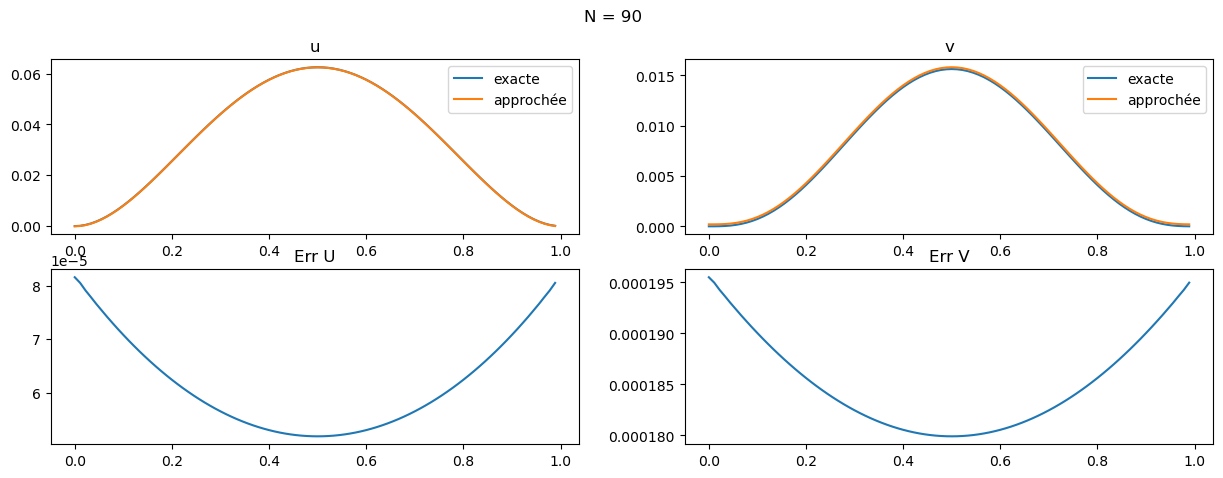

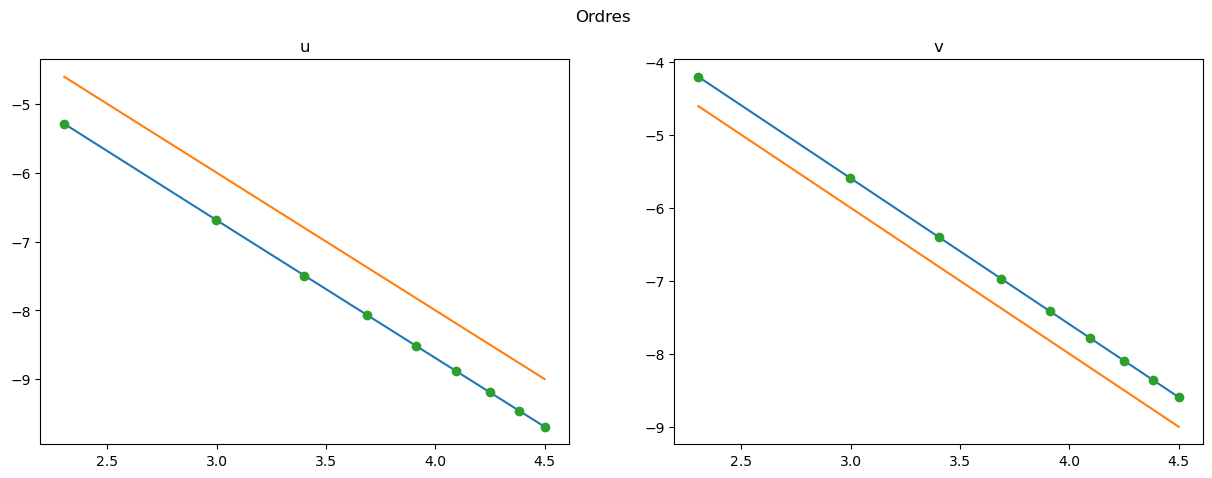

l'ordre u est :  2.003835549430615
l'ordre v est :  1.9987136187726255


In [88]:
Ns = np.arange(10,100,10)
Err = [[],[]]
for N in Ns :
	(Eu , Ev) = resol(N)
	Err[0].append(Eu)
	Err[1].append(Ev)


fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ordres')
axs[0].set_title('u')
axs[0].plot(log(Ns),log(Err[0]), log(Ns), -2*log(Ns))
axs[0].plot(log(Ns),log(Err[0]),'o')

axs[1].set_title('v')
axs[1].plot(log(Ns),log(Err[1]), log(Ns), -2*log(Ns))
axs[1].plot(log(Ns),log(Err[1]),'o')
plt.show()

print("l'ordre u est : ", -polyfit(log(Ns),log(Err[0]),1)[0])
print("l'ordre v est : ", -polyfit(log(Ns),log(Err[1]),1)[0])